In [44]:
import os
import numpy as np
import pandas as pd
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
import warnings
warnings.filterwarnings('ignore')

In [45]:
file_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/two_class_raw_5s_no.csv'

In [48]:
features = pd.read_csv(file_path)
features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
print(f"Tuning hyperparameters for 5s_no ...")
cv_folds = 10

X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

# split data
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]


model = RandomForestClassifier(random_state=42)

# Apply SMOTE-Tomek to training fold only
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train, y_train
)

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

# Fit model
model.fit(X_train_resampled, y_train_encoded)

# Predict
# predictions = label_encoder.inverse_transform(model.predict(X_test))


Tuning hyperparameters for 5s_no ...


RandomForestClassifier(random_state=42)

In [49]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test))
y_pred_prob = model.predict_proba(X_test)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

    non-void       0.72      0.93      0.81        76
        void       0.80      0.42      0.55        48

    accuracy                           0.73       124
   macro avg       0.76      0.68      0.68       124
weighted avg       0.75      0.73      0.71       124



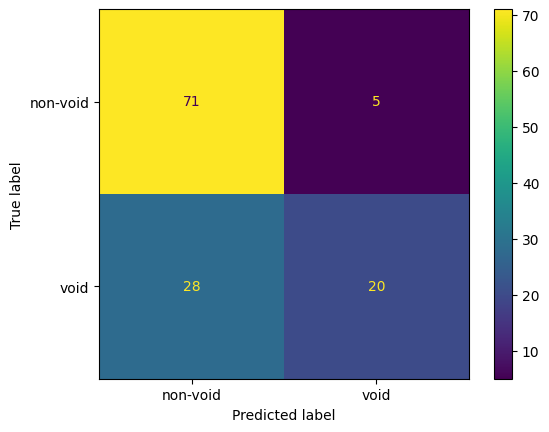

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.show()

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 200, 300, 500]),
    max_depth = trial.suggest_categorical('max_depth', [None, 3, 5, 7, 10, 15, 20]),
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10, 20]),
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2, 4, 8]),
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    bootstrap = trial.suggest_categorical('bootstrap', [True, False]),
    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 200, 300, 500]),
    max_depth = trial.suggest_categorical('max_depth', [None, 3, 5, 7, 10, 15, 20]),
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10, 20]),
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2, 4, 8]),
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    bootstrap = trial.suggest_categorical('bootstrap', [True, False]),
    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])

# Initialize GroupKFold
gkf = GroupKFold(n_splits=cv_folds)
fold_scores = []
# Perform cross-validation
for fold_idx, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X_train, y_train, groups_train)):
                
    # Split data for this fold
    X_train_fold, X_test_fold = X_train.iloc[train_idx_fold], X_train.iloc[test_idx_fold]
    y_train_fold, y_test_fold = y_train.iloc[train_idx_fold], y_train.iloc[test_idx_fold]
                    
    # Apply SMOTE-Tomek to training fold only
    smote_tomek = SMOTETomek(random_state=42)
    X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
        X_train_fold, y_train_fold
    )
                        
    # Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_resampled)
                    

    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)

                    
    # Train on resampled fold training data
    model.fit(X_train_resampled, y_train_encoded)
                    
    # Predict on fold validation data (original, unbalanced)
    y_pred = label_encoder.inverse_transform(model.predict(X_test_fold))
                    
                    
    # Calculate F1 score for this fold
    fold_score = f1_score(y_test_fold, y_pred, average='weighted')
    fold_scores.append(fold_score)

In [40]:
n_cpu = os.cpu_count()
print("Number of CPUs in the system:", n_cpu)

Number of CPUs in the system: 12


In [41]:
def objective(trial):
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 200, 300, 500])
    max_depth = trial.suggest_categorical('max_depth', [None, 3, 5, 7, 10, 15, 20])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10, 20])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2, 4, 8])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    
    # Create params dictionary
    params = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'bootstrap': bootstrap,
        'class_weight': class_weight
    }
    
    # Initialize GroupKFold
    gkf = GroupKFold(n_splits=cv_folds)
    fold_scores = []
    
    # Perform cross-validation
    for fold_idx, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X_train, y_train, groups_train)):
        
        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx_fold], X_train.iloc[test_idx_fold]
        y_train_fold, y_test_fold = y_train.iloc[train_idx_fold], y_train.iloc[test_idx_fold]
        
        # Apply SMOTE-Tomek to training fold only
        smote_tomek = SMOTETomek(random_state=42)
        X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
            X_train_fold, y_train_fold
        )
        
        # Encode labels
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train_resampled)
        
        # Initialize model with suggested parameters
        model = RandomForestClassifier(random_state=42, n_jobs= n_cpu - 1, **params)
        
        # Train on resampled fold training data
        model.fit(X_train_resampled, y_train_encoded)
        
        # Predict on fold validation data (original, unbalanced)
        y_pred = label_encoder.inverse_transform(model.predict(X_test_fold))
        
        # Calculate F1 score for this fold
        fold_score = f1_score(y_test_fold, y_pred, average='weighted')
        fold_scores.append(fold_score)
    
    # Return mean F1 score across all folds
    return np.mean(fold_scores)

In [ ]:
def model_performance(model, X=X_test, y=y_test): 
    """
    Get accuracy score on validation/test data and the recall of the void class from a trained model
    """
    
    label_encoder.inverse_transform(model.predict(X_test))
    return round(accuracy_score(y, y_pred), 3)

In [51]:
model_performance(model)

0.734